# Phase 2.1: Data Configuration
- Clean data (used processed data from Naive Experiments (After VED2))
- Investigate missing data
- Divided into 3 datasets: ICE, FEV, HPEV
- Each would have a different approach to calculate `Energy Consumption`

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Naive Experiments/VED_final_data.csv")
df = df.drop(columns="Unnamed: 0")

/var/folders/zh/znnjbxzs5hqbkljnm3f8zf9w0000gn/T/ipykernel_15743/1180009158.py:1: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Naive Experiments/VED_final_data.csv")


In [3]:
df.dtypes

vehid                   int64
trip                    int64
timestamp               int64
speed_kmh             float64
maf_gsec              float64
rpm                   float64
absload               float64
temp_degc             float64
fuelrate_lhr          float64
ac_kw                 float64
ac_watts              float64
heater_watts          float64
hv_battery_current    float64
hv_battery_soc        float64
hv_battery_voltage    float64
stft_bank1            float64
stft_bank2            float64
ltft_bank1            float64
ltft_bank2            float64
vehicle_class          object
engine_config          object
transmission           object
drive_wheels           object
generalized_weight     object
vehicle_type           object
hour                    int64
day_of_week             int64
month                   int64
day_of_year             int64
hour_sin              float64
hour_cos              float64
dow_sin               float64
dow_cos               float64
doy_sin   

In [3]:
df

,vehid,trip,timestamp,speed_kmh,maf_gsec,rpm,absload,temp_degc,fuelrate_lhr,ac_kw,...,dow_sin,dow_cos,doy_sin,doy_cos,road_class,displacement,stft_avg,ltft_avg,rho_air,fcr
0,10,2095,0,51.439999,NaN,NaN,NaN,1.000000,NaN,NaN,...,0.974928,-0.222521,0.951057,0.309017,Main,NaN,0.00000,0.00000,1.249130,NaN
1,10,2095,100,52.849998,NaN,NaN,NaN,1.000000,NaN,NaN,...,0.974928,-0.222521,0.951057,0.309017,Main,NaN,0.00000,0.00000,1.249130,NaN
2,10,2095,1100,54.129997,NaN,NaN,NaN,1.000000,NaN,NaN,...,0.974928,-0.222521,0.951057,0.309017,Main,NaN,0.00000,0.00000,1.249130,NaN
3,10,2095,2200,55.250000,NaN,NaN,NaN,1.000000,NaN,NaN,...,0.974928,-0.222521,0.951057,0.309017,Main,NaN,0.00000,0.00000,1.249130,NaN
4,10,2095,2300,55.250000,NaN,NaN,NaN,1.000000,NaN,NaN,...,0.974928,-0.222521,0.951057,0.309017,Main,NaN,0.00000,0.00000,1.249130,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22436803,609,590,309300,51.000000,16.600000,1343.0,NaN,27.358999,NaN,NaN,...,0.781831,0.623490,-0.145799,-0.989314,Main,3.8,0.00000,-3.90625,1.139563,1.132923
22436804,609,590,311400,52.000000,16.629999,1309.0,NaN,27.358999,NaN,NaN,...,0.781831,0.623490,-0.145799,-0.989314,Main,3.8,0.00000,-3.90625,1.139563,1.134971
22436805,609,590,312100,52.000000,16.629999,1309.0,NaN,27.358999,NaN,NaN,...,0.781831,0.623490,-0.145799,-0.989314,Main,3.8,0.00000,-3.90625,1.139563,1.134971
22436806,609,590,312800,53.000000,16.629999,1309.0,NaN,27.358999,NaN,NaN,...,0.781831,0.623490,-0.145799,-0.989314,Main,3.8,2.34375,-3.90625,1.139563,1.162653


In [5]:
df.describe()

,vehid,trip,timestamp,speed_kmh,maf_gsec,rpm,absload,temp_degc,fuelrate_lhr,ac_kw,...,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos,displacement,stft_avg,ltft_avg,rho_air,fcr
count,2.243681e+07,2.243681e+07,2.243681e+07,2.243541e+07,1.825814e+07,2.195450e+07,1.647160e+07,2.243681e+07,896097.000000,894275.000000,...,2.243681e+07,2.243681e+07,2.243681e+07,2.243681e+07,2.243681e+07,2.177734e+07,2.243681e+07,2.243681e+07,2.243681e+07,2.130668e+07
mean,3.986763e+02,1.557964e+03,4.570035e+05,4.039923e+01,9.674235e+00,1.168221e+03,2.959461e+01,1.132089e+01,0.883316,1.045491,...,-2.269819e-02,-7.134714e-02,-1.204292e-01,4.478747e-04,7.487662e-02,2.327330e+00,1.117931e-01,7.337309e-01,1.205813e+00,7.311373e-01
std,1.441625e+02,1.150565e+03,5.653689e+05,2.692629e+01,1.031936e+01,7.519340e+02,7.134866e+01,1.165546e+01,2.361895,2.012678,...,7.454999e-01,7.057234e-01,6.945221e-01,6.957654e-01,7.143556e-01,8.149393e-01,3.825077e+00,3.938934e+00,4.891700e-02,8.938348e-01
min,2.000000e+00,2.000000e+00,-1.658400e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-4.000000e+01,0.000000,0.000000,...,-1.000000e+00,-9.749279e-01,-9.009689e-01,-9.999907e-01,-9.999630e-01,1.000000e+00,-1.000000e+02,-5.039062e+01,1.027913e+00,-0.000000e+00
25%,2.930000e+02,9.150000e+02,1.262000e+05,1.900000e+01,2.700000e+00,7.000000e+02,1.450980e+01,-7.500000e-01,0.000000,0.000000,...,-8.660254e-01,-7.818315e-01,-9.009689e-01,-6.870528e-01,-6.453481e-01,1.800000e+00,-7.812500e-01,-7.812500e-01,1.160254e+00,1.903808e-01
50%,4.290000e+02,1.372000e+03,2.988000e+05,4.300000e+01,5.400000e+00,1.242000e+03,2.431373e+01,7.455794e+00,0.000000,0.000000,...,-1.836970e-16,0.000000e+00,-2.225209e-01,-8.606997e-03,1.585594e-01,2.000000e+00,0.000000e+00,0.000000e+00,1.220392e+00,3.882502e-01
75%,5.280000e+02,1.919000e+03,5.788000e+05,5.815000e+01,1.447000e+01,1.649000e+03,4.470588e+01,2.200000e+01,0.000000,0.680000,...,7.071068e-01,4.338837e-01,6.234898e-01,6.807734e-01,7.829801e-01,2.500000e+00,7.812500e-01,2.343750e+00,1.257155e+00,1.056796e+00
max,6.300000e+02,1.158000e+04,1.012090e+07,1.730000e+02,2.593100e+02,6.605000e+03,2.246353e+04,6.000000e+01,83.599998,6.360000,...,1.000000e+00,9.749279e-01,1.000000e+00,9.999907e-01,1.000000e+00,6.800000e+00,8.984375e+01,5.781250e+01,1.468793e+00,8.360000e+01


In [4]:
df[["vehid", "trip"]] = df[["vehid", "trip"]].astype("str")

In [5]:
fcr_null = df[df['fcr'].isnull()]

In [6]:
fcr_null[["vehicle_type", "vehicle_class", "engine_config", "hv_battery_voltage", "hv_battery_current", "fcr"]]

,vehicle_type,vehicle_class,engine_config,hv_battery_voltage,hv_battery_current,fcr
0,EV,Car,ELECTRIC,371.0,-48.5,NaN
1,EV,Car,ELECTRIC,371.0,-48.5,NaN
2,EV,Car,ELECTRIC,371.0,-48.5,NaN
3,EV,Car,ELECTRIC,371.0,-48.5,NaN
4,EV,Car,ELECTRIC,371.0,-48.0,NaN
...,...,...,...,...,...,...
22372045,ICE,NO DATA,4-FI 2.3L ULEV,NaN,NaN,NaN
22372046,ICE,NO DATA,4-FI 2.3L ULEV,NaN,NaN,NaN
22372047,ICE,NO DATA,4-FI 2.3L ULEV,NaN,NaN,NaN
22372048,ICE,NO DATA,4-FI 2.3L ULEV,NaN,NaN,NaN


In [7]:
fcr_null.groupby('vehicle_type').count()

,vehid,trip,timestamp,speed_kmh,maf_gsec,rpm,absload,temp_degc,fuelrate_lhr,ac_kw,...,dow_sin,dow_cos,doy_sin,doy_cos,road_class,displacement,stft_avg,ltft_avg,rho_air,fcr
vehicle_type,,,,,,,,,,,,,,,,,,,,,
EV,476308,476308,476308,476308,0,0,0,476308,0,0,...,476308,476308,476308,476308,476308,0,476308,476308,476308,0
HEV,17349,17349,17349,17011,0,16906,0,17349,0,0,...,17349,17349,17349,17349,17349,17349,17349,17349,17349,0
ICE,636470,636470,636470,635412,0,630916,0,636470,0,0,...,636470,636470,636470,636470,636470,636470,636470,636470,636470,0


## Energy Consumption metric
According to the dataset's methodology, the OBD-II data loggers recorded the Battery Current as negative when the battery is discharging (providing power to propel the vehicle) and positive when the battery is charging (such as during regenerative braking or plugging in)
=> we need to invert the sign

- Positive values should represent the power being consumed from the battery to move the vehicle, which typically happens during acceleration and cruising
- Negative values should represent the power being recovered and put back into the battery via regenerative braking

In [8]:
electric_power = (df['hv_battery_voltage'] * df['hv_battery_current']) / 1000 * (-1)
df['fcr'] = df['fcr'].fillna(electric_power)

In [9]:
fcr_null = df[df['fcr'].isnull()]
fcr_null[["vehicle_type", "vehicle_class", "engine_config", "hv_battery_voltage", "hv_battery_current", "fcr"]]

,vehicle_type,vehicle_class,engine_config,hv_battery_voltage,hv_battery_current,fcr
1287,ICE,NO DATA,4-FI 2.2L,NaN,NaN,NaN
1288,ICE,NO DATA,4-FI 2.2L,NaN,NaN,NaN
1289,ICE,NO DATA,4-FI 2.2L,NaN,NaN,NaN
1290,ICE,NO DATA,4-FI 2.2L,NaN,NaN,NaN
1291,ICE,NO DATA,4-FI 2.2L,NaN,NaN,NaN
...,...,...,...,...,...,...
22372045,ICE,NO DATA,4-FI 2.3L ULEV,NaN,NaN,NaN
22372046,ICE,NO DATA,4-FI 2.3L ULEV,NaN,NaN,NaN
22372047,ICE,NO DATA,4-FI 2.3L ULEV,NaN,NaN,NaN
22372048,ICE,NO DATA,4-FI 2.3L ULEV,NaN,NaN,NaN


In [10]:
fcr_null.groupby('vehicle_type').vehid.count()/df.groupby('vehicle_type').vehid.count()

vehicle_type
EV           NaN
HEV     0.003105
ICE     0.048476
PHEV         NaN
Name: vehid, dtype: float64

In [11]:
df[df.vehicle_type=='EV']

,vehid,trip,timestamp,speed_kmh,maf_gsec,rpm,absload,temp_degc,fuelrate_lhr,ac_kw,...,dow_sin,dow_cos,doy_sin,doy_cos,road_class,displacement,stft_avg,ltft_avg,rho_air,fcr
0,10,2095,0,51.439999,NaN,NaN,NaN,1.0,NaN,NaN,...,0.974928,-0.222521,0.951057,0.309017,Main,NaN,0.0,0.0,1.249130,17.99350
1,10,2095,100,52.849998,NaN,NaN,NaN,1.0,NaN,NaN,...,0.974928,-0.222521,0.951057,0.309017,Main,NaN,0.0,0.0,1.249130,17.99350
2,10,2095,1100,54.129997,NaN,NaN,NaN,1.0,NaN,NaN,...,0.974928,-0.222521,0.951057,0.309017,Main,NaN,0.0,0.0,1.249130,17.99350
3,10,2095,2200,55.250000,NaN,NaN,NaN,1.0,NaN,NaN,...,0.974928,-0.222521,0.951057,0.309017,Main,NaN,0.0,0.0,1.249130,17.99350
4,10,2095,2300,55.250000,NaN,NaN,NaN,1.0,NaN,NaN,...,0.974928,-0.222521,0.951057,0.309017,Main,NaN,0.0,0.0,1.249130,17.80800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22258522,10,2710,434400,0.000000,NaN,NaN,NaN,35.0,NaN,NaN,...,-0.974928,-0.222521,-0.094537,-0.995521,Main,NaN,0.0,0.0,1.111306,1.91750
22258523,10,2710,435500,0.000000,NaN,NaN,NaN,35.0,NaN,NaN,...,-0.974928,-0.222521,-0.094537,-0.995521,Main,NaN,0.0,0.0,1.111306,1.53400
22258524,10,2710,436500,0.000000,NaN,NaN,NaN,35.0,NaN,NaN,...,-0.974928,-0.222521,-0.094537,-0.995521,Main,NaN,0.0,0.0,1.111306,1.72575
22258525,10,2710,440700,0.000000,NaN,NaN,NaN,35.0,NaN,NaN,...,-0.974928,-0.222521,-0.094537,-0.995521,Main,NaN,0.0,0.0,1.111306,1.91750


In [12]:
df = df.rename(columns={'fcr': 'encon'})

In [13]:
fcr_null.columns

Index(['vehid', 'trip', 'timestamp', 'speed_kmh', 'maf_gsec', 'rpm', 'absload',
       'temp_degc', 'fuelrate_lhr', 'ac_kw', 'ac_watts', 'heater_watts',
       'hv_battery_current', 'hv_battery_soc', 'hv_battery_voltage',
       'stft_bank1', 'stft_bank2', 'ltft_bank1', 'ltft_bank2', 'vehicle_class',
       'engine_config', 'transmission', 'drive_wheels', 'generalized_weight',
       'vehicle_type', 'hour', 'day_of_week', 'month', 'day_of_year',
       'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos',
       'road_class', 'displacement', 'stft_avg', 'ltft_avg', 'rho_air', 'fcr'],
      dtype='object')

## Null Value Investigation

In [16]:
fcr_null[['maf_gsec', 'fuelrate_lhr', 'absload', 'displacement', 'rpm', 'rho_air', 'stft_avg', 'ltft_avg']]

,maf_gsec,fuelrate_lhr,absload,displacement,rpm,rho_air,stft_avg,ltft_avg
1287,NaN,NaN,NaN,2.2,1321.0,1.238535,0.0000,0.78125
1288,NaN,NaN,NaN,2.2,1321.0,1.238535,3.1250,0.78125
1289,NaN,NaN,NaN,2.2,2015.0,1.238535,3.1250,0.78125
1290,NaN,NaN,NaN,2.2,2015.0,1.238535,3.1250,0.78125
1291,NaN,NaN,NaN,2.2,2015.0,1.238535,3.1250,0.78125
...,...,...,...,...,...,...,...,...
22372045,NaN,NaN,NaN,2.3,1247.0,1.139563,0.0000,3.90625
22372046,NaN,NaN,NaN,2.3,1198.0,1.139563,-4.6875,3.90625
22372047,NaN,NaN,NaN,2.3,1198.0,1.139563,-4.6875,3.90625
22372048,NaN,NaN,NaN,2.3,1198.0,1.139563,-4.6875,3.90625


In [19]:
fcr_null[['maf_gsec', 'fuelrate_lhr', 'absload', 'displacement', 'rpm', 'rho_air', 'stft_avg', 'ltft_avg']].isnull().sum()

maf_gsec        653819
fuelrate_lhr    653819
absload         653819
displacement         0
rpm               5997
rho_air              0
stft_avg             0
ltft_avg             0
dtype: int64

In [21]:
fcr_null = fcr_null.rename(columns={'fcr': 'encon'})

Rows with null FCR comes from null MAF (cannot calculate FCR) or Absload (cannot calculate MAF)

In [29]:
# 1. Count of unique cars (vehid) with null values per vehicle type
cars_per_type = fcr_null.groupby('vehicle_type')['vehid'].nunique()

# 2. Count of unique trips with null values per vehicle type
trips_per_type = fcr_null.groupby('vehicle_type')['trip'].nunique()

# 3. Average and total null timestamps per trip, grouped by vehicle type
# We group by vehicle_type and trip first to see the density of nulls
nulls_per_trip = fcr_null.groupby(['vehicle_type', 'trip']).size().reset_index(name='null_timestamp_count')

# Summarize the trip-level frequency
frequency_summary = nulls_per_trip.groupby('vehicle_type')['null_timestamp_count'].agg(['mean', 'max', 'sum']).rename(columns={
    'mean': 'Avg Nulls per Trip',
    'max': 'Max Nulls in a Single Trip',
    'sum': 'Total Null Timestamps'
})

# Combine everything into one report
report = pd.DataFrame({
    'Unique Cars': cars_per_type,
    'Total Trips with Nulls': trips_per_type
}).join(frequency_summary)

print("Analysis of Null FCR Values")
report

Analysis of Null FCR Values


,Unique Cars,Total Trips with Nulls,Avg Nulls per Trip,Max Nulls in a Single Trip,Total Null Timestamps
vehicle_type,,,,,
HEV,5,50,346.980000,621,17349
ICE,21,1068,595.945693,2782,636470


In [30]:
# 5 minutes in milliseconds (assuming 'timestamp' is in ms)
five_min_ms = 5 * 60 * 1000

# 1. Determine trip boundaries for all trips
# We use the main 'df' to ensure we know the true start and end of every trip
trip_bounds = df.groupby(['vehid', 'trip'])['timestamp'].agg(['min', 'max']).reset_index()
trip_bounds.columns = ['vehid', 'trip', 'trip_start', 'trip_end']

# 2. Identify the rows with null values
target_col = 'encon' 
null_data = df[df[target_col].isnull()].copy()

# 3. Merge trip boundaries to the null data
null_data = null_data.merge(trip_bounds, on=['vehid', 'trip'], how='left')

# 4. Calculate relative position
null_data['ms_from_start'] = null_data['timestamp'] - null_data['trip_start']
null_data['ms_to_end'] = null_data['trip_end'] - null_data['timestamp']

# 5. Categorize the timing
def categorize_position(row):
    if row['ms_from_start'] <= five_min_ms:
        return 'First 5 Minutes'
    elif row['ms_to_end'] <= five_min_ms:
        return 'Last 5 Minutes'
    else:
        return 'Middle'

null_data['trip_position'] = null_data.apply(categorize_position, axis=1)

# 6. Display Summary
summary = null_data.groupby(['vehicle_type', 'trip_position']).size().unstack(fill_value=0)
summary_pct = summary.div(summary.sum(axis=1), axis=0) * 100

print("--- Distribution of Null FCR Values ---")
print("\nCounts:")
print(summary)
print("\nPercentages (%):")
print(summary_pct.round(2))

--- Distribution of Null FCR Values ---

Counts:
trip_position  First 5 Minutes  Last 5 Minutes  Middle
vehicle_type                                          
HEV                      12644            4334     371
ICE                     323434          181083  131953

Percentages (%):
trip_position  First 5 Minutes  Last 5 Minutes  Middle
vehicle_type                                          
HEV                      72.88           24.98    2.14
ICE                      50.82           28.45   20.73


- First 5 Minutes: If nulls cluster here, it often points to initialization delays in the OBD-II logger or the vehicle's ECU not reporting specific PIDs until a warm-up sequence begins.

- Last 5 Minutes: High counts here could indicate the logger shutting down before the trip actually ends (e.g., when the engine is turned off but the vehicle is still rolling or idling).

- Middle: If the majority are in the middle, the issue is likely intermittent signal loss or specific driving conditions (like extreme acceleration or idling) that cause the calculation formula to fail.

/var/folders/zh/znnjbxzs5hqbkljnm3f8zf9w0000gn/T/ipykernel_4595/165894718.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


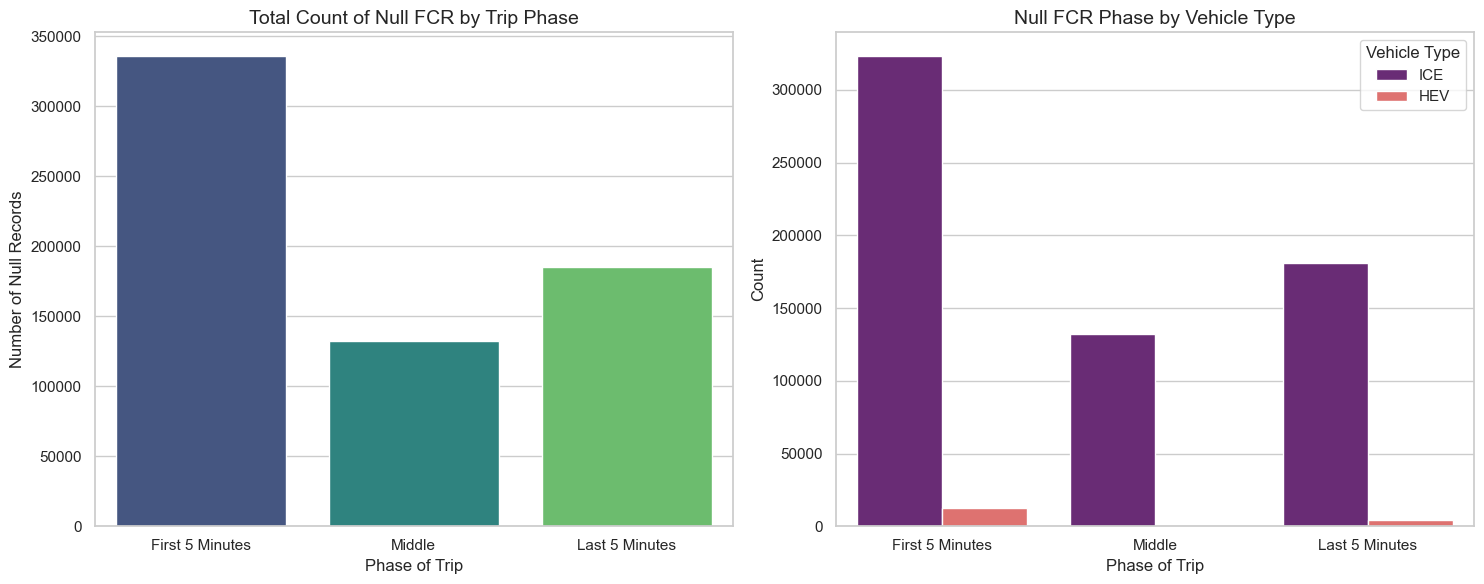

In [32]:
# Ensure the categories are ordered logically for the charts
order = ['First 5 Minutes', 'Middle', 'Last 5 Minutes']

# Set the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Chart 1: Overall distribution of Nulls
sns.countplot(
    data=null_data, 
    x='trip_position', 
    order=order, 
    ax=axes[0], 
    palette='viridis')
axes[0].set_title('Total Count of Null FCR by Trip Phase', fontsize=14)
axes[0].set_xlabel('Phase of Trip')
axes[0].set_ylabel('Number of Null Records')
# Chart 2: Distribution by Vehicle Type
sns.countplot(
    data=null_data, 
    x='trip_position', 
    hue='vehicle_type', 
    order=order, 
    ax=axes[1], 
    palette='magma'
)
axes[1].set_title('Null FCR Phase by Vehicle Type', fontsize=14)
axes[1].set_xlabel('Phase of Trip')
axes[1].set_ylabel('Count')
axes[1].legend(title='Vehicle Type', loc='upper right')

plt.tight_layout()
plt.show()

In [43]:
df

,vehid,trip,timestamp,speed_kmh,maf_gsec,rpm,absload,temp_degc,fuelrate_lhr,ac_kw,...,dow_sin,dow_cos,doy_sin,doy_cos,road_class,displacement,stft_avg,ltft_avg,rho_air,encon
0,10,2095,0,51.439999,NaN,NaN,NaN,1.000000,NaN,NaN,...,0.974928,-0.222521,0.951057,0.309017,Main,NaN,0.00000,0.00000,1.249130,17.993500
1,10,2095,100,52.849998,NaN,NaN,NaN,1.000000,NaN,NaN,...,0.974928,-0.222521,0.951057,0.309017,Main,NaN,0.00000,0.00000,1.249130,17.993500
2,10,2095,1100,54.129997,NaN,NaN,NaN,1.000000,NaN,NaN,...,0.974928,-0.222521,0.951057,0.309017,Main,NaN,0.00000,0.00000,1.249130,17.993500
3,10,2095,2200,55.250000,NaN,NaN,NaN,1.000000,NaN,NaN,...,0.974928,-0.222521,0.951057,0.309017,Main,NaN,0.00000,0.00000,1.249130,17.993500
4,10,2095,2300,55.250000,NaN,NaN,NaN,1.000000,NaN,NaN,...,0.974928,-0.222521,0.951057,0.309017,Main,NaN,0.00000,0.00000,1.249130,17.808000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22436803,609,590,309300,51.000000,16.600000,1343.0,NaN,27.358999,NaN,NaN,...,0.781831,0.623490,-0.145799,-0.989314,Main,3.8,0.00000,-3.90625,1.139563,1.132923
22436804,609,590,311400,52.000000,16.629999,1309.0,NaN,27.358999,NaN,NaN,...,0.781831,0.623490,-0.145799,-0.989314,Main,3.8,0.00000,-3.90625,1.139563,1.134971
22436805,609,590,312100,52.000000,16.629999,1309.0,NaN,27.358999,NaN,NaN,...,0.781831,0.623490,-0.145799,-0.989314,Main,3.8,0.00000,-3.90625,1.139563,1.134971
22436806,609,590,312800,53.000000,16.629999,1309.0,NaN,27.358999,NaN,NaN,...,0.781831,0.623490,-0.145799,-0.989314,Main,3.8,2.34375,-3.90625,1.139563,1.162653


In [44]:
ice = df[df.vehicle_type == 'ICE']
ice.to_csv("ICEV_dataset.csv")

In [45]:
hev = df[df.vehicle_type == 'HEV']
hev.to_csv("HEV_dataset.csv")

In [46]:
phev = df[df.vehicle_type == 'PHEV']
phev.to_csv("PHEV_dataset.csv")

In [47]:
ev = df[df.vehicle_type == 'EV']
ev.to_csv("EV_dataset.csv")